### Классификация новостей по категориям Lenta.ru
Вариант 2.

Выполняли: Билалова И,  Еникеев Т.

Задачи:
1. Анализ датасета и выбор признаков
2. Предварительная обработка текстов
3. Тематическое моделирование (WordCloud + LDA)
4. Векторизация
5. Классификация (3 модели + оценка качества)
6. Парсинг данных 
7. Разработка API 
8. Разработка приложения
9. Документация
10. Итоговый отчет

### Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pymorphy3 import MorphAnalyzer
import pymorphy3

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
!pip install gensim
import gensim

# import joblib
# nltk.download('stopwords', quiet=True)

### Загрузка и анализ датасета

In [8]:
df = pd.read_csv('lenta-ru-news.csv') 

In [9]:
df.head()

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


### Описание набора данных
* **URL**  Cсылка новостной статьи
* **TITLE**  Заголовок  статьи
* **TEXT**  Текст  статьи
* **TOPIC**  Тема  статьи
* **TAGS**  Теги  статьи
* **DATE**  Дата публикации  статьи

In [10]:
# Размер датасета 
df.shape

(800975, 6)

In [11]:
# Информация о колонках
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800975 entries, 0 to 800974
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     800975 non-null  object
 1   title   800975 non-null  object
 2   text    800970 non-null  object
 3   topic   738973 non-null  object
 4   tags    773756 non-null  object
 5   date    800975 non-null  object
dtypes: object(6)
memory usage: 36.7+ MB


Размер датасета 800975 записей, тип данных object

#### Обрезаем датасет на 300,000 новостей.

In [12]:
 df = df.sample(300000, random_state=42)

In [13]:
df.shape

(300000, 6)

In [14]:
df.isnull().sum()

url          0
title        0
text         1
topic    23149
tags     10226
date         0
dtype: int64

In [130]:
# пропущены значения в text (1), topic (23149) и tags(10226)

**Объединяем заголовок и текст** 

In [15]:
df['full_text'] = df['title'].fillna('') + ". " + df['text'].fillna('')

##### **Выбор признаков**

In [16]:
# Оставляем только значимые поля
selected_columns = ['full_text', 'topic']
df_selected = df[selected_columns].copy()

# Удаляем строки с пропусками в тексте
df_selected = df_selected.dropna(subset=['full_text', 'topic'])

print(f"Размер после очистки: {df_selected.shape} \n")
print(f"Категории: {df_selected['topic'].unique()}")

Размер после очистки: (276851, 2) 

Категории: ['Культура' 'Наука и техника' 'Мир' 'Интернет и СМИ' 'Россия' 'Из жизни'
 'Экономика' 'Спорт' 'Бывший СССР' 'Силовые структуры' 'Дом' 'Бизнес'
 'Путешествия' '69-я параллель' 'Ценности' 'Крым' 'Легпром'
 'Культпросвет ' 'Библиотека' 'МедНовости' 'ЧМ-2014' 'Оружие']


##### Выбранные атрибуты:
1. text - Основной источник информации для классификации. Содержит ключевые слова и контекст
2. topic - Целевая переменная (метка класса)
##### Исключенные поля:
1. url - Уникальный идентификатор, не несет смысловой нагрузки для классификации
2. title - Коррелирует с текстом, может внести шум
3. tags	- Часто отсутствует
4. date	- Временная метка не влияет на тематику новости

In [17]:
print("\nРаспределение категорий: ")
print(df_selected['topic'].value_counts())


Распределение категорий: 
topic
Россия               60022
Мир                  51108
Экономика            29877
Спорт                24041
Культура             20192
Бывший СССР          20031
Наука и техника      19804
Интернет и СМИ       16966
Из жизни             10344
Дом                   8078
Силовые структуры     7298
Ценности              2985
Бизнес                2792
Путешествия           2382
69-я параллель         475
Крым                   254
Культпросвет           128
Легпром                 41
Библиотека              29
ЧМ-2014                  2
МедНовости               1
Оружие                   1
Name: count, dtype: int64


In [18]:
# Удаляем категории с очень малым количеством примеров (< 50)
# Это улучшит качество моделей
category_counts = df_selected['topic'].value_counts()
categories_to_keep = category_counts[category_counts >= 50].index.tolist()
df_filtered = df_selected[df_selected['topic'].isin(categories_to_keep)]

In [19]:
print("\nРаспределение категорий после фильтрации:")
print(df_filtered['topic'].value_counts())
print(f"Новый размер датасета: {df_filtered.shape}")


Распределение категорий после фильтрации:
topic
Россия               60022
Мир                  51108
Экономика            29877
Спорт                24041
Культура             20192
Бывший СССР          20031
Наука и техника      19804
Интернет и СМИ       16966
Из жизни             10344
Дом                   8078
Силовые структуры     7298
Ценности              2985
Бизнес                2792
Путешествия           2382
69-я параллель         475
Крым                   254
Культпросвет           128
Name: count, dtype: int64
Новый размер датасета: (276777, 2)


In [20]:
# Сохраним отфильтрованный датасет для дальнейшей работы
df_filtered.to_csv('lenta_filtered.csv', index=False)

In [21]:
df_filtered = pd.read_csv('lenta_filtered.csv') 

### Предварительная обработка текстов

In [22]:
df_filtered['full_text'][0]

'Жена Оззи Осборна выиграла суд против британского таблоида. Жена лидера британской группы Black Sabbath Оззи Осборна Шэрон выиграла суд против таблоида The Sun. Об этом сообщает издание New Musical Express. Представители издания согласились с решением суда и признали, что нанесли семье Осборнов моральный вред, напечатав статью о методах, которыми пользовалась Осборн во время работы менеджером Black Sabbath. Речь идет о публикации, появившейся в The Sun в октябре 2007 года. Автор текста утверждал, что Шэрон "практически уничтожила своего немощного мужа", а также подвергла его жизнь риску, заставляя работать в напряженном режиме. В статье также рассказывается, что жена Осборна настаивала на том, чтобы музыкант давал живые концерты тогда, когда он был не в лучшей форме. В тексте публикации утверждается, что фронтмен Black Sabbath должен был таким образом заработать деньги, чтобы его супруга могла "продолжать свои непомерные траты". Согласно решению суда, The Sun возместит семье Осборнов 

In [23]:
df_filtered['full_text'][6300]

'Финская старушка до\xa0смерти напугала лосенка. 300-килограммовый лосенок в пятницу ворвался в дом 75-летней жительницы Финляндии, сообщает Reuters. По сообщению полиции, старушка собиралась выпить утренний кофе на кухне своего дома, когда разъяренное животное пробило дверь террасы и пронеслось мимо нее в гостиную. Оказавшись в доме, лосенок начал крушить мебель. "Скорее всего лосенок увидел свое отражение в стекле террасы, принял его за соперника и атаковал", - заявил представитель местной полиции Эро Коскинен (Eero Koskinen). В течение четырех часов полиция и представители общества охраны дикой природы пытались выманить животное на улицу, однако лосенок отказывался покидать дом старушки.  В итоге полиции пришлось выстрелить в животное капсулой с транквилизатором. Усыпленный лосенок был отвезен в ближайший лес. Однако через некоторое время животное было найдено мертвым. "Эта игра оказалось для него слишком жестокой" - заявил Коскинен. Хозяйка дома была доставлена в состоянии шока в м

In [31]:
# формирование корпуса
df_filtered['corpus'] = df_filtered['full_text'].fillna('').astype(str)

In [32]:
st = '\n—\xa0'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [33]:
df_filtered['prep_text']= [remove_othersymbol(text.lower()) for text in df_filtered['corpus']]

In [34]:
df_filtered['full_text'][0]

'Жена Оззи Осборна выиграла суд против британского таблоида. Жена лидера британской группы Black Sabbath Оззи Осборна Шэрон выиграла суд против таблоида The Sun. Об этом сообщает издание New Musical Express. Представители издания согласились с решением суда и признали, что нанесли семье Осборнов моральный вред, напечатав статью о методах, которыми пользовалась Осборн во время работы менеджером Black Sabbath. Речь идет о публикации, появившейся в The Sun в октябре 2007 года. Автор текста утверждал, что Шэрон "практически уничтожила своего немощного мужа", а также подвергла его жизнь риску, заставляя работать в напряженном режиме. В статье также рассказывается, что жена Осборна настаивала на том, чтобы музыкант давал живые концерты тогда, когда он был не в лучшей форме. В тексте публикации утверждается, что фронтмен Black Sabbath должен был таким образом заработать деньги, чтобы его супруга могла "продолжать свои непомерные траты". Согласно решению суда, The Sun возместит семье Осборнов 

In [35]:
df_filtered['full_text'][6300]

'Финская старушка до\xa0смерти напугала лосенка. 300-килограммовый лосенок в пятницу ворвался в дом 75-летней жительницы Финляндии, сообщает Reuters. По сообщению полиции, старушка собиралась выпить утренний кофе на кухне своего дома, когда разъяренное животное пробило дверь террасы и пронеслось мимо нее в гостиную. Оказавшись в доме, лосенок начал крушить мебель. "Скорее всего лосенок увидел свое отражение в стекле террасы, принял его за соперника и атаковал", - заявил представитель местной полиции Эро Коскинен (Eero Koskinen). В течение четырех часов полиция и представители общества охраны дикой природы пытались выманить животное на улицу, однако лосенок отказывался покидать дом старушки.  В итоге полиции пришлось выстрелить в животное капсулой с транквилизатором. Усыпленный лосенок был отвезен в ближайший лес. Однако через некоторое время животное было найдено мертвым. "Эта игра оказалось для него слишком жестокой" - заявил Коскинен. Хозяйка дома была доставлена в состоянии шока в м

In [25]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [37]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [38]:
df_filtered['prep_text']= [remove_punctuation(text) for text in df_filtered['prep_text']]

In [39]:
df_filtered['prep_text'][0]

'жена оззи осборна выиграла суд против британского таблоида жена лидера британской группы black sabbath оззи осборна шэрон выиграла суд против таблоида the sun об этом сообщает издание new musical express представители издания согласились с решением суда и признали что нанесли семье осборнов моральный вред напечатав статью о методах которыми пользовалась осборн во время работы менеджером black sabbath речь идет о публикации появившейся в the sun в октябре 2007 года автор текста утверждал что шэрон практически уничтожила своего немощного мужа а также подвергла его жизнь риску заставляя работать в напряженном режиме в статье также рассказывается что жена осборна настаивала на том чтобы музыкант давал живые концерты тогда когда он был не в лучшей форме в тексте публикации утверждается что фронтмен black sabbath должен был таким образом заработать деньги чтобы его супруга могла продолжать свои непомерные траты согласно решению суда the sun возместит семье осборнов моральный вред а также из

In [40]:
df_filtered.head()

,full_text,topic,clean_text,prep_text,corpus
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...,Жена Оззи Осборна выиграла суд против британск...
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...,В Осло вручили международную премию Абеля по м...
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...,Сбивший полицейского российский дипломат покин...
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...,Рен ТВ сменил слоган и эфирное оформление. Тел...
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...,Госдуме предложили не пускать в Россию мигрант...


#### Лемматизация

In [26]:
import nltk
russian_stopwords = stopwords.words("russian") 

In [27]:
russian_stopwords = set(stopwords.words("russian"))
russian_stopwords.update([
    'т.д.', 'т', 'д', 'это', 'который', 'свой', 'своём', 'всем', 'всё', 'её',
    'оба', 'ещё', 'так', 'весь', 'быть', 'мочь', 'сказать'
])

In [28]:
nltk.download('punkt_tab', quiet=True)

True

In [29]:
morph = pymorphy3.MorphAnalyzer(lang='ru')  #Создается объект morph для лемматизации.

In [45]:
##Лемитизация с кжшом

from functools import lru_cache

@lru_cache(maxsize=50000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

lemm_texts_list = []
for text in df_filtered['prep_text']:
    try:
        tokens = word_tokenize(text)
        lemm_texts_list.append(" ".join(lemmatize_word(w) for w in tokens))
    except:
        lemm_texts_list.append("")

In [46]:
df_filtered['text_lemm'] = lemm_texts_list

In [47]:
df_filtered.head()

,full_text,topic,clean_text,prep_text,corpus,text_lemm
0,Жена Оззи Осборна выиграла суд против британск...,Культура,Жена Оззи Осборна выиграла суд против британск...,жена оззи осборна выиграла суд против британск...,Жена Оззи Осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...
1,В Осло вручили международную премию Абеля по м...,Наука и техника,В Осло вручили международную премию Абеля по м...,в осло вручили международную премию абеля по м...,В Осло вручили международную премию Абеля по м...,в осло вручить международный премия абель по м...
2,Сбивший полицейского российский дипломат покин...,Мир,Сбивший полицейского российский дипломат покин...,сбивший полицейского российский дипломат покин...,Сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменил слоган и эфирное оформление теле...,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменить слоган и эфирный оформление тел...
4,Госдуме предложили не пускать в Россию мигрант...,Россия,Госдуме предложили не пускать в Россию мигрант...,госдуме предложили не пускать в россию мигрант...,Госдуме предложили не пускать в Россию мигрант...,госдума предложить не пускать в россия мигрант...


In [48]:
df_filtered['text_lemm'][0]

'жена оззь осборн выиграть суд против британский таблоид жена лидер британский группа black sabbath оззь осборн шэрон выиграть суд против таблоид the sun о это сообщать издание new musical express представитель издание согласиться с решение суд и признать что нанести семья осборн моральный вред напечатать статья о метод который пользоваться осборн в время работа менеджер black sabbath речь идти о публикация появиться в the sun в октябрь 2007 год автор текст утверждать что шэрон практически уничтожить свой немощный муж а также подвергнуть он жизнь риск заставлять работать в напрячь режим в статья также рассказываться что жена осборн настаивать на тот чтобы музыкант давать живой концерт тогда когда он быть не в хороший форма в текст публикация утверждаться что фронтмен black sabbath должный быть такой образ заработать деньга чтобы он супруг мочь продолжать свой непомерный трата согласно решение суд the sun возместить семья осборн моральный вред а также издержка сумма который не разглашат

In [49]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(token) > 2]
    text = " ".join(tokens)
    return text

**Разбиваем на слова удаляем список стоп-слов и слова длиной 2 символа**

In [50]:
df_filtered['tokenize_text'] = [tokenize(text) for text in df_filtered['text_lemm']]

In [60]:
df_filtered['clean_text'] = df_filtered['tokenize_text']

In [61]:
df_filtered.head()

,full_text,topic,clean_text,prep_text,corpus,text_lemm,tokenize_text,tokenize_text3
0,Жена Оззи Осборна выиграла суд против британск...,Культура,жена оззь осборн выиграть суд против британски...,жена оззи осборна выиграла суд против британск...,Жена Оззи Осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,"[жена, оззь, осборн, выиграть, суд, против, бр..."
1,В Осло вручили международную премию Абеля по м...,Наука и техника,осло вручить международный премия абель матема...,в осло вручили международную премию абеля по м...,В Осло вручили международную премию Абеля по м...,в осло вручить международный премия абель по м...,осло вручить международный премия абель матема...,"[осло, вручить, международный, премия, абель, ..."
2,Сбивший полицейского российский дипломат покин...,Мир,сбить полицейский российский дипломат покинуть...,сбивший полицейского российский дипломат покин...,Сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,"[сбить, полицейский, российский, дипломат, пок..."
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,рен сменить слоган эфирный оформление телекана...,рен тв сменил слоган и эфирное оформление теле...,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменить слоган и эфирный оформление тел...,рен сменить слоган эфирный оформление телекана...,"[рен, сменить, слоган, эфирный, оформление, те..."
4,Госдуме предложили не пускать в Россию мигрант...,Россия,госдума предложить пускать россия мигрант день...,госдуме предложили не пускать в россию мигрант...,Госдуме предложили не пускать в Россию мигрант...,госдума предложить не пускать в россия мигрант...,госдума предложить пускать россия мигрант день...,"[госдума, предложить, пускать, россия, мигрант..."


**Финальный очищенный текст**

In [58]:
df_filtered['clean_text'][0]

'жена оззь осборн выиграть суд против британский таблоид жена лидер британский группа black sabbath оззь осборн шэрон выиграть суд против таблоид the sun сообщать издание new musical express представитель издание согласиться решение суд признать нанести семья осборн моральный вред напечатать статья метод пользоваться осборн время работа менеджер black sabbath речь идти публикация появиться the sun октябрь 2007 год автор текст утверждать шэрон практически уничтожить немощный муж также подвергнуть жизнь риск заставлять работать напрячь режим статья также рассказываться жена осборн настаивать музыкант давать живой концерт хороший форма текст публикация утверждаться фронтмен black sabbath должный образ заработать деньга супруг продолжать непомерный трата согласно решение суд the sun возместить семья осборн моральный вред также издержка сумма разглашаться издание принести извинение публикация статья признать сведение шэрон осборн появиться газета являться неверный'

In [56]:
df_filtered.to_pickle('lenta_processed_final.pkl')
print("Сохранено")

Сохранено


In [23]:
df_filtered = pd.read_pickle('lenta_processed_final.pkl')

**РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ**

In [6]:
# Для обучения используем clean_text
X = df_filtered['clean_text']
y = df_filtered['topic']

# Дальше train_test_split, векторизация и т.д.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
print(f"\nРазмер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"\nРаспределение категорий в обучении:")
print(y_train.value_counts().head(10))


Размер обучающей выборки: 221421
Размер тестовой выборки: 55356

Распределение категорий в обучении:
topic
Россия             48017
Мир                40886
Экономика          23902
Спорт              19233
Культура           16154
Бывший СССР        16025
Наука и техника    15843
Интернет и СМИ     13573
Из жизни            8275
Дом                 6462
Name: count, dtype: int64


### Векторизация текстовых данных

### Bag of words

In [81]:
# CountVectorizer для LDA (LDA лучше работает с частотами)
count_vec = CountVectorizer(max_df=0.85, min_df=5, max_features=5000, ngram_range=(1, 2), analyzer='word')
count_matrix = count_vec.fit_transform(df_filtered['clean_text'])

feature_names = count_vec.get_feature_names_out()

In [9]:
len(count_vec.vocabulary_)

5000

In [10]:
count_matrix.shape

(276777, 5000)

In [11]:
print(list(feature_names))

['100', '100 миллион', '100 процент', '100 тысяча', '1000', '105', '110', '120', '125', '130', '140', '150', '1500', '160', '180', '1989', '1990', '1990 год', '1990ха', '1990ха год', '1991', '1991 год', '1992', '1992 год', '1993', '1993 год', '1994', '1994 год', '1995', '1995 год', '1996', '1996 год', '1997', '1997 год', '1998', '1998 год', '1999', '1999 год', '200', '200 тысяча', '2000', '2000 год', '2001', '2001 год', '2002', '2002 год', '2003', '2003 год', '2004', '2004 год', '2005', '2005 год', '2006', '2006 год', '2007', '2007 год', '2008', '2008 год', '2009', '2009 год', '2010', '2010 год', '2011', '2011 год', '2012', '2012 год', '2013', '2013 год', '2014', '2014 год', '2015', '2015 год', '2015го', '2016', '2016 год', '2016го', '2017', '2017 год', '2018', '2018 год', '2019', '2019 год', '2020', '2020 год', '250', '300', '300 тысяча', '350', '360', '400', '450', '500', '500 тысяча', '600', '700', '800', '900', 'afp', 'agence', 'agence francepresse', 'air', 'airbus', 'airlines', 'a

### TF-IDF

In [12]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,          # игнорировать слова, встречающиеся в >70% документов
    min_df=3,            # игнорировать слова, встречающиеся менее чем в 3 документах
    max_features=5000,   # ограничить размер словаря
    ngram_range=(1, 2),  
    analyzer='word'
)

In [13]:
# Обучаем TF-IDF на тренировочных данных
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Трансформируем тестовые данные (без обучения)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [14]:
print(f"TF-IDF матрица обучение: {X_train_tfidf.shape}")
print(f"TF-IDF матрица тест: {X_test_tfidf.shape}")

TF-IDF матрица обучение: (221421, 5000)
TF-IDF матрица тест: (55356, 5000)


In [15]:
tfidf_matrix_lsa = tfidf_vectorizer.fit_transform(df_filtered['clean_text'])

In [16]:
feature_names = tfidf_vectorizer.get_feature_names_out()[150:160]

In [17]:
import joblib
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("Векторизатор сохранен в 'tfidf_vectorizer.pkl'")

joblib.dump(count_vec, 'count_vec.pkl')
print("CountVectorizer сохранен в 'count_vectorizer.pkl'")

Векторизатор сохранен в 'tfidf_vectorizer.pkl'
CountVectorizer сохранен в 'count_vectorizer.pkl'


### Тематическое моделирование (LDA, NMF, LSA)

In [60]:
pip install WordCloud

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# Получение облака слов
def get_wordCloud(data_series):
    """Уменьшенная версия для очень больших данных"""
    # Берем только первые 50,000 строк для облака слов
    sample_data = data_series[:20000]
    corpus_text = ' '.join(sample_data)
    
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=1500,
                              height=1000,
                              max_words=200,
                              random_state=42
                         ).generate(corpus_text)
    
    return wordCloud

# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

In [10]:
procWordCloud = get_wordCloud(df_filtered['tokenize_text'].values)

fig = plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [11]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

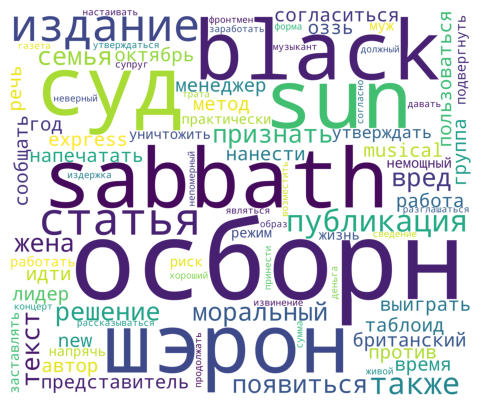

In [216]:
corpus = df_filtered['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show() 

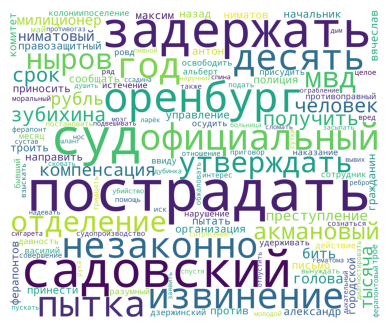

In [15]:
corpus = df_filtered['tokenize_text'][400]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(25, 4))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.show() 

In [21]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(token) > 2]
    return tokens

In [30]:
df_filtered['tokenize_text3'] = [tokenize2(text) for text in df_filtered['clean_text']]

In [31]:
gensim_dictionary = gensim.corpora.Dictionary(df_filtered['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=20)
gensim_dictionary.compactify()

In [32]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df_filtered['tokenize_text3']]

In [33]:
df_filtered.head()

,full_text,topic,clean_text,prep_text,corpus,text_lemm,tokenize_text,tokenize_text3
0,Жена Оззи Осборна выиграла суд против британск...,Культура,жена оззь осборн выиграть суд против британски...,жена оззи осборна выиграла суд против британск...,Жена Оззи Осборна выиграла суд против британск...,жена оззь осборн выиграть суд против британски...,жена оззь осборн выиграть суд против британски...,"[жена, оззь, осборн, выиграть, суд, против, бр..."
1,В Осло вручили международную премию Абеля по м...,Наука и техника,осло вручить международный премия абель матема...,в осло вручили международную премию абеля по м...,В Осло вручили международную премию Абеля по м...,в осло вручить международный премия абель по м...,осло вручить международный премия абель матема...,"[осло, вручить, международный, премия, абель, ..."
2,Сбивший полицейского российский дипломат покин...,Мир,сбить полицейский российский дипломат покинуть...,сбивший полицейского российский дипломат покин...,Сбивший полицейского российский дипломат покин...,сбить полицейский российский дипломат покинуть...,сбить полицейский российский дипломат покинуть...,"[сбить, полицейский, российский, дипломат, пок..."
3,Рен ТВ сменил слоган и эфирное оформление. Тел...,Интернет и СМИ,рен сменить слоган эфирный оформление телекана...,рен тв сменил слоган и эфирное оформление теле...,Рен ТВ сменил слоган и эфирное оформление. Тел...,рен тв сменить слоган и эфирный оформление тел...,рен сменить слоган эфирный оформление телекана...,"[рен, сменить, слоган, эфирный, оформление, те..."
4,Госдуме предложили не пускать в Россию мигрант...,Россия,госдума предложить пускать россия мигрант день...,госдуме предложили не пускать в россию мигрант...,Госдуме предложили не пускать в Россию мигрант...,госдума предложить не пускать в россия мигрант...,госдума предложить пускать россия мигрант день...,"[госдума, предложить, пускать, россия, мигрант..."


In [34]:
corpus

[[(0, 1),
  (1, 3),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 3),
  (6, 3),
  (7, 3),
  (8, 1),
  (9, 2),
  (10, 1),
  (11, 2),
  (12, 2),
  (13, 1),
  (14, 1),
  (15, 3),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 3),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 2),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 2),
  (39, 1),
  (40, 7),
  (41, 1),
  (42, 1),
  (43, 2),
  (44, 1),
  (45, 2),
  (46, 1),
  (47, 1),
  (48, 3),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 2),
  (56, 1),
  (57, 1),
  (58, 3),
  (59, 1),
  (60, 1),
  (61, 2),
  (62, 2),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 3)],
 [(59, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1),
  (82, 2),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 6),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1

In [35]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [36]:
lda_20.print_topics()

[(0,
  '0.011*"миллиард" + 0.007*"банк" + 0.006*"рынок" + 0.006*"цена" + 0.005*"акция" + 0.005*"составить" + 0.004*"крупный" + 0.004*"нефть" + 0.003*"финансовый" + 0.003*"объём"'),
 (1,
  '0.010*"украина" + 0.006*"военный" + 0.005*"украинский" + 0.004*"министр" + 0.004*"государство" + 0.004*"лидер" + 0.004*"республика" + 0.004*"территория" + 0.003*"партия" + 0.003*"сила"'),
 (2,
  '0.006*"метр" + 0.006*"строительство" + 0.006*"площадь" + 0.005*"проект" + 0.005*"квадратный" + 0.005*"дом" + 0.004*"центр" + 0.004*"здание" + 0.004*"олимпийский" + 0.003*"пройти"'),
 (3,
  '0.009*"матч" + 0.006*"команда" + 0.005*"бывший" + 0.005*"сборная" + 0.005*"клуб" + 0.004*"счёт" + 0.004*"чемпионат" + 0.004*"депутат" + 0.004*"выборы" + 0.004*"адвокат"'),
 (4,
  '0.008*"полиция" + 0.008*"задержать" + 0.007*"погибнуть" + 0.006*"пострадать" + 0.005*"дом" + 0.005*"взрыв" + 0.005*"район" + 0.004*"мужчина" + 0.004*"полицейский" + 0.004*"убийство"'),
 (5,
  '0.011*"самолёт" + 0.006*"учёный" + 0.005*"система" +

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

In [73]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

# 🔑 КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ:
# Берем ПОЛНЫЙ словарь из векторизатора, на котором обучалась LDA (count_vec),
# а не обрезанный срез от tfidf_vectorizer.
feature_names = count_vec.get_feature_names_out()

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)


KeyboardInterrupt: 

In [68]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)

lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method='online',
    batch_size=2048,         
    max_iter=15,           
    n_jobs=-1,               
    random_state=42,
    verbose=1               
)

lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)


KeyboardInterrupt: 

In [ ]:
# n_topics = 7
# n_top_words = 10

# print("\n" + "="*60)
# print("LDA (Латентное размещение Дирихле)")
# print("="*60)
# lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
# lda.fit(count_matrix)

# def print_topics(model, feature_names, n_top_words):
#     for topic_idx, topic in enumerate(model.components_):
#         print(f"Тема {topic_idx + 1}:")
#         top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
#         top_words = [feature_names[i] for i in top_words_idx]
#         print(" ".join(top_words))
#         print()

# print_topics(lda, feature_names, n_top_words)

In [ ]:
!pip install pyldavis
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [ ]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [ ]:
pyLDAvis.enable_notebook()

In [ ]:
vis_20

In [ ]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df_filtered['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

#### Когерентность модели LDA составила =0.609 (хороший результат для русского языка). 

In [72]:
# создание модели LDA
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

KeyboardInterrupt: 

In [ ]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

In [ ]:
#датафрейм для ключевых слов каждой темы
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

* LDA ХОРОШИЙ РЕЗУЛЬТАТ
* 
7 тем, но некоторые пересекаются
*
Темы понятны, но менее детализированы
*
Детализация Меньше тем → более общие категории
*
Когерентность
0.609 — хороший показатель

In [ ]:
from sklearn.decomposition import NMF

In [70]:
# создание модели NMF
nmf_model = NMF(n_components=10, random_state=0, max_iter=1000)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

NameError: name 'NMF' is not defined

In [71]:
# создание модели NMF
nmf_model = NMF(n_components=7, random_state=0, max_iter=1000)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

NameError: name 'NMF' is not defined

In [ ]:
from sklearn.decomposition import TruncatedSVD

In [ ]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

* LSA  — НАИМЕНЕЕ УДАЧНАЯ
* Темы размыты, слова повторяются
* Темы перекрываются, сложно разделить


#### Вывод


Лучшая модель NMF
1. Более точное разделение тем
2. Работа с разреженными данными
NMF лучше справляется с разреженной TF-IDF матрицей текстов
3.  Неотрицательность компонентов
Все веса ≥ 0 → темы интерпретируются как "наборы слов", а не разности
4.  Практическая применимость
Темы напрямую соответствуют рубрикам новостного сайта:
Спорт, Политика, Экономика, Происшествия, Кино, Право, Авиация
Менее чувствительна к редким словам, чем LDA


In [69]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 НОВОСТИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx+1}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        text = df_filtered.iloc[doc_idx]['text'][:150]
        topic = df_filtered.iloc[doc_idx]['topic']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {text}  (категория: {topic}) — уверенность: {score:.3f}")
    print()

NameError: name 'nmf_model' is not defined

# Отчёт: Классификация новостей Lenta.ru

##  1. Введение
**Цель:** Разработка модели машинного обучения для автоматической категоризации русскоязычных новостных статей.

**Датасет:** 
- Источник: [Lenta.Ru-News Dataset](https://github.com/yutkin/Lenta.Ru-News-Dataset)
- Объём: 800 975 статей → 276 776 после фильтрации
- Категории: 24 → 17 (удалены классы с <50 примеров)
- Период: 1990–2020 гг.

##  2. Методология

### 2.1 Предобработка текстов
```python
Pipeline:
1. Приведение к нижнему регистру
2. Удаление спецсимволов и пунктуации
3. Токенизация (NLTK)
4. Лемматизация (pymorphy3) + кэширование
5. Удаление стоп-слов (расширенный список, 200+ слов)
6. Фильтрация токенов: len(token) > 2, isalpha()

### Классификация

In [ ]:
# Для обучения используем clean_text
X = df_filtered['clean_text']
y = df_filtered['topic']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### LogisticRegression

In [76]:
results = {}
lr = LogisticRegression(C=1.5,            
    max_iter=1000, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced' )
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

results['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
print("LogisticRegression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LogisticRegression
Accuracy: 0.7968422573885396
                   precision    recall  f1-score   support

   69-я параллель       0.33      0.75      0.46        95
           Бизнес       0.39      0.76      0.52       558
      Бывший СССР       0.79      0.87      0.83      4006
              Дом       0.76      0.88      0.82      1616
         Из жизни       0.53      0.75      0.62      2069
   Интернет и СМИ       0.73      0.76      0.75      3393
             Крым       0.26      0.76      0.39        51
    Культпросвет        0.19      0.50      0.27        26
         Культура       0.88      0.87      0.87      4038
              Мир       0.84      0.76      0.80     10222
  Наука и техника       0.83      0.83      0.83      3961
      Путешествия       0.50      0.82      0.62       476
           Россия       0.87      0.69      0.77     12005
Силовые структуры       0.47      0.80      0.59      1460
            Спорт       0.96      0.96      0.96      4808
       

#### Random Forest

In [79]:
rf = RandomForestClassifier( n_estimators=100,
                            max_depth=50, 
                            random_state=42, 
                            n_jobs=-1,
                            class_weight='balanced')
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)

results['Random Fores'] = accuracy_score(y_test, rf_pred)
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

KeyboardInterrupt: 

#### LinearSVC

In [78]:
svm = LinearSVC( C=1.0, 
                max_iter=3000,      
                random_state=42, 
                dual='auto',
                class_weight='balanced')
svm.fit(X_train_tfidf, y_train)  

svm_pred = svm.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, svm_pred)

print(f"Accuracy: {accuracy_svm:.4f}")
print(classification_report(y_test, svm_pred))

Accuracy: 0.8150
                   precision    recall  f1-score   support

   69-я параллель       0.53      0.59      0.56        95
           Бизнес       0.48      0.68      0.56       558
      Бывший СССР       0.80      0.88      0.84      4006
              Дом       0.80      0.88      0.83      1616
         Из жизни       0.59      0.70      0.64      2069
   Интернет и СМИ       0.74      0.76      0.75      3393
             Крым       0.50      0.59      0.54        51
    Культпросвет        0.35      0.23      0.28        26
         Культура       0.86      0.89      0.88      4038
              Мир       0.84      0.79      0.81     10222
  Наука и техника       0.82      0.85      0.84      3961
      Путешествия       0.60      0.82      0.69       476
           Россия       0.86      0.75      0.80     12005
Силовые структуры       0.55      0.71      0.62      1460
            Спорт       0.96      0.97      0.96      4808
         Ценности       0.84      0.89

#### Сравнение моделей

In [41]:
print("LogisticRegression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

LogisticRegression: 0.8212659874268372
Random Forest: 0.7570633716308982
SVM: 0.8248789652431534


**Матрица ошибок** 

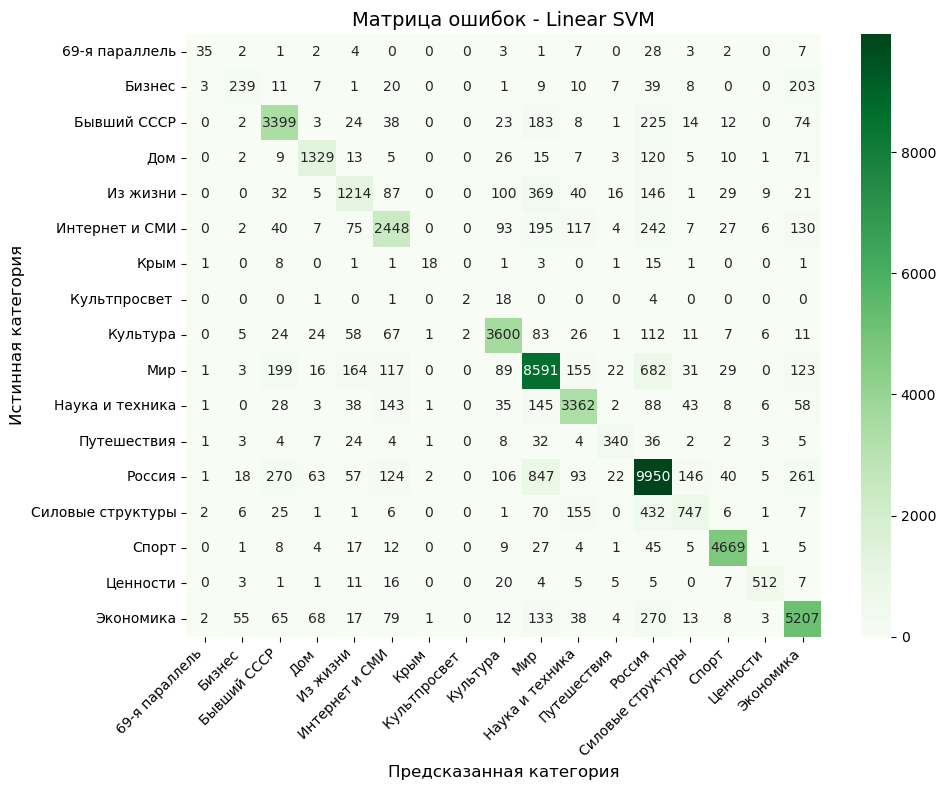

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title("Матрица ошибок - Linear SVM", fontsize=14)
plt.xlabel("Предсказанная категория", fontsize=12)
plt.ylabel("Истинная категория", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(rf_clf, f)

In [ ]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(count_matrix, f)

In [ ]:
joblib.dump(rf, "model_LineSVC.pkl")

In [50]:
import pickle
import joblib
import os
import json
from datetime import datetime

In [51]:
pickle.dump(svm, open('model.pkl', 'wb'))
joblib.dump(svm, 'model.joblib')

# Сохраняем векторизатор
pickle.dump(tfidf_vectorizer, open('vectorizer.pkl', 'wb'))
joblib.dump(tfidf_vectorizer, 'vectorizer.joblib')

['vectorizer.joblib']

✅ Лучшая модель: Linear SVM
✅ Точность: 0.8150
✅ Функция clean_text определена


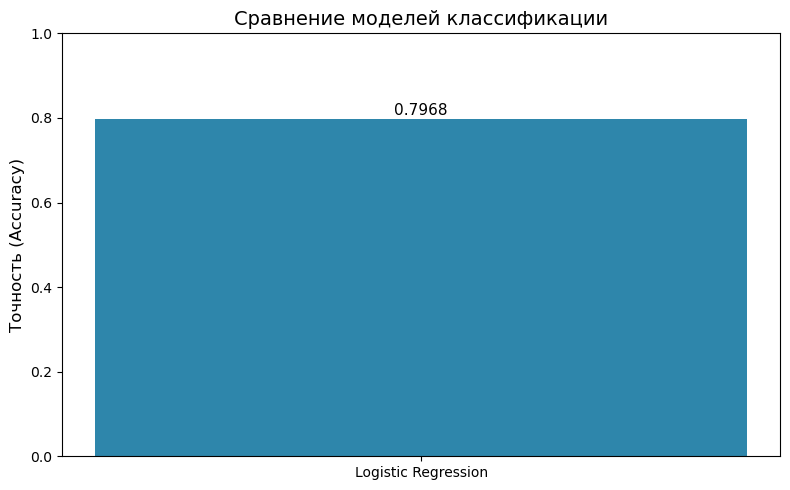

✅ График сравнения моделей построен

ТЕСТИРОВАНИЕ НА ПРИМЕРАХ

📰 Текст: Путин встретился с президентом США в Москве
🏷️ Категория: Наука и техника | 📊 Уверенность: N/A

📰 Текст: Зенит выиграл чемпионат России по футболу
🏷️ Категория: Спорт | 📊 Уверенность: N/A

📰 Текст: Apple представила новый iPhone
🏷️ Категория: Наука и техника | 📊 Уверенность: N/A

📰 Текст: Цены на нефть упали до 60 долларов за баррель
🏷️ Категория: Экономика | 📊 Уверенность: N/A

📰 Текст: Финская старушка до смерти напугала лосенка
🏷️ Категория: Россия | 📊 Уверенность: N/A

📰 Текст: Жена Оззи Осборна выиграла суд против британского таблоида
🏷️ Категория: Из жизни | 📊 Уверенность: N/A

📰 Текст: Национальное общество кинокритиков определило лучшие киноработы 2002 года, сообщает Reuters
🏷️ Категория: Из жизни | 📊 Уверенность: N/A

📰 Текст: Табачные изделия в России за год (март 2016-го к марту 2015-го) выросли в цене на 25,3 процента
🏷️ Категория: Наука и техника | 📊 Уверенность: N/A


In [80]:
# ================================
# СНАЧАЛА ОПРЕДЕЛИМ best_model (какая модель лучшая)
# ================================

# Вариант 1: Если вы обучили SVM и он лучший
best_model = svm
best_model_name = "Linear SVM"
best_accuracy = accuracy_svm

# ИЛИ Вариант 2: Если лучшая Logistic Regression
# best_model = lr
# best_model_name = "Logistic Regression"
# best_model_accuracy = accuracy_lr

# ИЛИ Вариант 3: Если лучшая Random Forest
# best_model = rf
# best_model_name = "Random Forest"
# best_model_accuracy = accuracy_rf

print(f"✅ Лучшая модель: {best_model_name}")
print(f"✅ Точность: {best_accuracy:.4f}")

# ================================
# ТЕПЕРЬ ВСЕ В ОДНОЙ ЯЧЕЙКЕ (гарантированно работает)
# ================================

import re
import string
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
import pickle
import joblib

# 1. Определяем стоп-слова
russian_stopwords = set(stopwords.words("russian"))
extra_stopwords = {
    'это', 'который', 'свой', 'своём', 'всем', 'всё', 'её', 'оба', 'ещё', 'так',
    'весь', 'быть', 'мочь', 'сказать', 'т.д.', 'т', 'д', 'также', 'является',
    'очень', 'потом', 'теперь', 'вот', 'тут', 'там', 'здесь', 'куда', 'откуда'
}
russian_stopwords.update(extra_stopwords)

# 2. Инициализируем морфологический анализатор
morph = pymorphy3.MorphAnalyzer(lang='ru')

# 3. Определяем функцию очистки
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    lemmatized = []
    for token in tokens:
        if token in russian_stopwords or len(token) < 3:
            continue
        try:
            lemma = morph.parse(token)[0].normal_form
            if len(lemma) >= 3:
                lemmatized.append(lemma)
        except:
            continue
    return ' '.join(lemmatized)

print("✅ Функция clean_text определена")

# 4. Визуализация сравнения моделей (если results существует)
try:
    plt.figure(figsize=(8, 5))
    models_names = list(results.keys())
    accuracies = list(results.values())

    colors = ['#2E86AB', '#A23B72', '#F18F01']
    bars = plt.bar(models_names, accuracies, color=colors)
    plt.ylim(0, 1)
    plt.ylabel('Точность (Accuracy)', fontsize=12)
    plt.title('Сравнение моделей классификации', fontsize=14)

    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.4f}', ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()
    print("✅ График сравнения моделей построен")
except NameError:
    print("⚠️ Переменная 'results' не найдена, пропускаем график")

# 5. Функция предсказания
def predict_category(news_text):
    cleaned = clean_text(news_text)
    vectorized = tfidf_vectorizer.transform([cleaned])
    category = best_model.predict(vectorized)[0]
    
    if hasattr(best_model, 'predict_proba'):
        proba = best_model.predict_proba(vectorized)[0]
        confidence = proba.max()
    else:
        confidence = None
    
    return category, confidence

# 6. Тестирование
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА ПРИМЕРАХ")
print("="*60)

test_examples = [
    "Путин встретился с президентом США в Москве",
    "Зенит выиграл чемпионат России по футболу",
    "Apple представила новый iPhone",
    "Цены на нефть упали до 60 долларов за баррель",
    "Финская старушка до смерти напугала лосенка",
    "Жена Оззи Осборна выиграла суд против британского таблоида",
    "Национальное общество кинокритиков определило лучшие киноработы 2002 года, сообщает Reuters",
    "Табачные изделия в России за год (март 2016-го к марту 2015-го) выросли в цене на 25,3 процента"
]

for text in test_examples:
    cat, conf = predict_category(text)
    conf_str = f"{conf:.2%}" if conf else "N/A"
    print(f"\n📰 Текст: {text}")
    print(f"🏷️ Категория: {cat} | 📊 Уверенность: {conf_str}")

In [75]:
# ================================
# ПРОСМОТР НОВОСТЕЙ ПО КАТЕГОРИЯМ
# ================================

# 1. Смотрим все уникальные категории
print("Все категории в датасете:")
print(df_filtered['topic'].unique())
print(f"\nВсего категорий: {df_filtered['topic'].nunique()}")

# 2. Смотрим количество новостей в каждой категории
print("\nКоличество новостей по категориям:")
print(df_filtered['topic'].value_counts())

# 3. Выбираем конкретную категорию и смотрим первые 5 новостей
category_name = 'Культура'  # поменяйте на любую категорию

print(f"\n--- Новости категории '{category_name}' ---")
category_news = df_filtered[df_filtered['topic'] == category_name]

for idx, row in category_news.head(5).iterrows():
    print(f"\nЗаголовок: {row['full_text'][:100]}...")
    print(f"Категория: {row['topic']}")
    print("-" * 50)

Все категории в датасете:
['Культура' 'Наука и техника' 'Мир' 'Интернет и СМИ' 'Россия' 'Из жизни'
 'Экономика' 'Спорт' 'Бывший СССР' 'Силовые структуры' 'Дом' 'Бизнес'
 'Путешествия' '69-я параллель' 'Ценности' 'Крым' 'Культпросвет ']

Всего категорий: 17

Количество новостей по категориям:
topic
Россия               60022
Мир                  51108
Экономика            29877
Спорт                24041
Культура             20192
Бывший СССР          20031
Наука и техника      19804
Интернет и СМИ       16966
Из жизни             10344
Дом                   8078
Силовые структуры     7298
Ценности              2985
Бизнес                2792
Путешествия           2382
69-я параллель         475
Крым                   254
Культпросвет           128
Name: count, dtype: int64

--- Новости категории 'Культура' ---

Заголовок: Жена Оззи Осборна выиграла суд против британского таблоида. Жена лидера британской группы Black Sabb...
Категория: Культура
------------------------------------------